#**Import Required Libraries**


In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#**Load Oxford Flowers 102 Dataset**

In [2]:
import tensorflow_datasets as tfds

(train_ds, valid_ds, test_ds), ds_info = tfds.load(
    "oxford_flowers102",
    split=["train", "validation", "test"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.XMLG65_2.1.1/oxford_flowers102-test.tfrecord-…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.XMLG65_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


#**Dataset Information**

In [3]:
print("Number of Classes:", ds_info.features["label"].num_classes)

print("Train Samples:", ds_info.splits["train"].num_examples)
print("Validation Samples:", ds_info.splits["validation"].num_examples)
print("Test Samples:", ds_info.splits["test"].num_examples)

Number of Classes: 102
Train Samples: 1020
Validation Samples: 1020
Test Samples: 6149


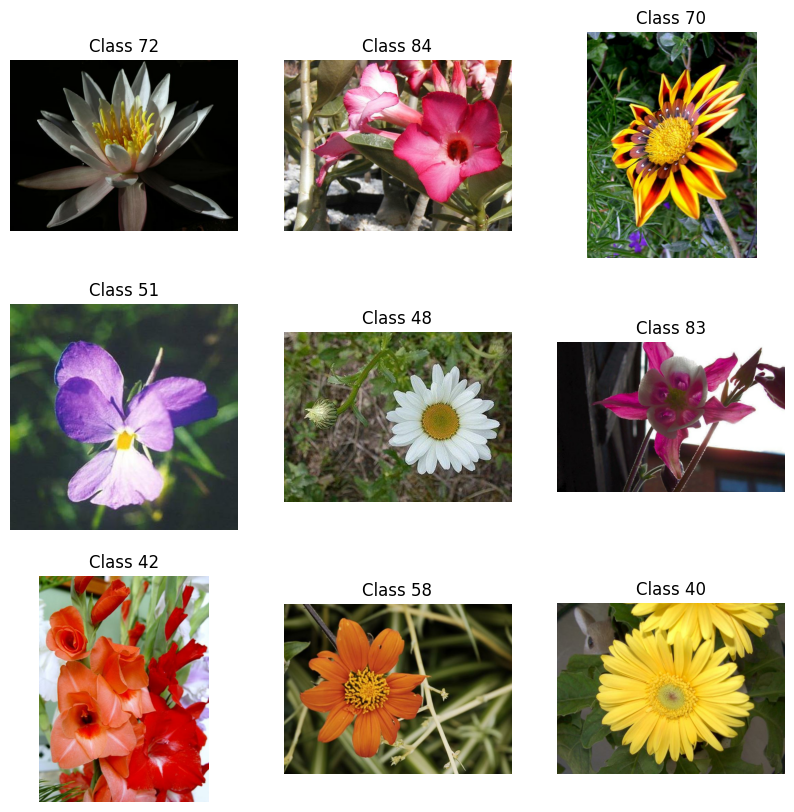

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(f"Class {label.numpy()}")
    plt.axis("off")

plt.show()

#**Data Preprocessing**

Visualize Sample Images

Image Preprocessing
Resize images and normalize pixel values

In [5]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1)
])

In [7]:
train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [8]:
BATCH_SIZE = 32

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_ds = valid_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


# **Build MobileNetV2 Transfer Learning Model**

Load Pretrained MobileNetV2

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###**Create Classification Head**

Build Complete MobileNetV2 Model

In [11]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    ds_info.features["label"].num_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

###**Display Model Architecture**

In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

###**Compile MobileNetV2 Model**

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

###**Define Training Callbacks**

Training Callbacks

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

###**Train Frozen MobileNetV2**

In [15]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 232ms/step - accuracy: 0.0637 - loss: 4.6578 - val_accuracy: 0.2549 - val_loss: 3.4208 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.3618 - loss: 2.8422 - val_accuracy: 0.5275 - val_loss: 2.4373 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.5588 - loss: 1.9656 - val_accuracy: 0.6108 - val_loss: 1.9370 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.7049 - loss: 1.4725 - val_accuracy: 0.6539 - val_loss: 1.6371 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.7676 - loss: 1.1400 - val_accuracy: 0.6980 - val_loss: 1.4379 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.8422 - loss: 0.9400 - val_accuracy: 0.7010 - val_loss: 1.3280 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.8451 - loss: 0.797

###**Evaluate Frozen MobileNetV2**

In [16]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.7312 - loss: 1.1664
Test Accuracy: 0.7311757802963257


###**Fine-Tuning MobileNetV2**

Unfreeze MobileNetV2 Layers

In [18]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

Recompile Model for Fine-Tuning

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Fine-Tune MobileNetV2

In [20]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.4422 - loss: 2.4572 - val_accuracy: 0.7490 - val_loss: 1.1115 - learning_rate: 1.0000e-05
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4728 - loss: 2.1649
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.4990 - loss: 2.0935 - val_accuracy: 0.7431 - val_loss: 1.1237 - learning_rate: 1.0000e-05
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.5471 - loss: 1.9045 - val_accuracy: 0.7500 - val_loss: 1.1075 - learning_rate: 2.0000e-06


In [21]:
test_loss, test_acc = model.evaluate(test_ds)

print("Fine-Tuned Test Accuracy:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7313 - loss: 1.1833
Fine-Tuned Test Accuracy: 0.7313384413719177


### **Save MobileNetV2 Results**

 **MobileNetV2 Results**

Frozen Test Accuracy = 73.12%

Fine-Tuned Test Accuracy = 73.13%

Best MobileNetV2 Accuracy = 73.13%

**Generate Predictions**

In [31]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = tf.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels.numpy())

**Import Evaluation Libraries**

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import seaborn as sns

**Calculate Evaluation Metrics**

In [33]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7313384290128476
Precision: 0.7363731690144888
Recall   : 0.7421507657799651
F1 Score : 0.7193850651562316


**Generate Confusion Matrix**

In [34]:
cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(102, 102)


**Visualize Confusion Matrix**

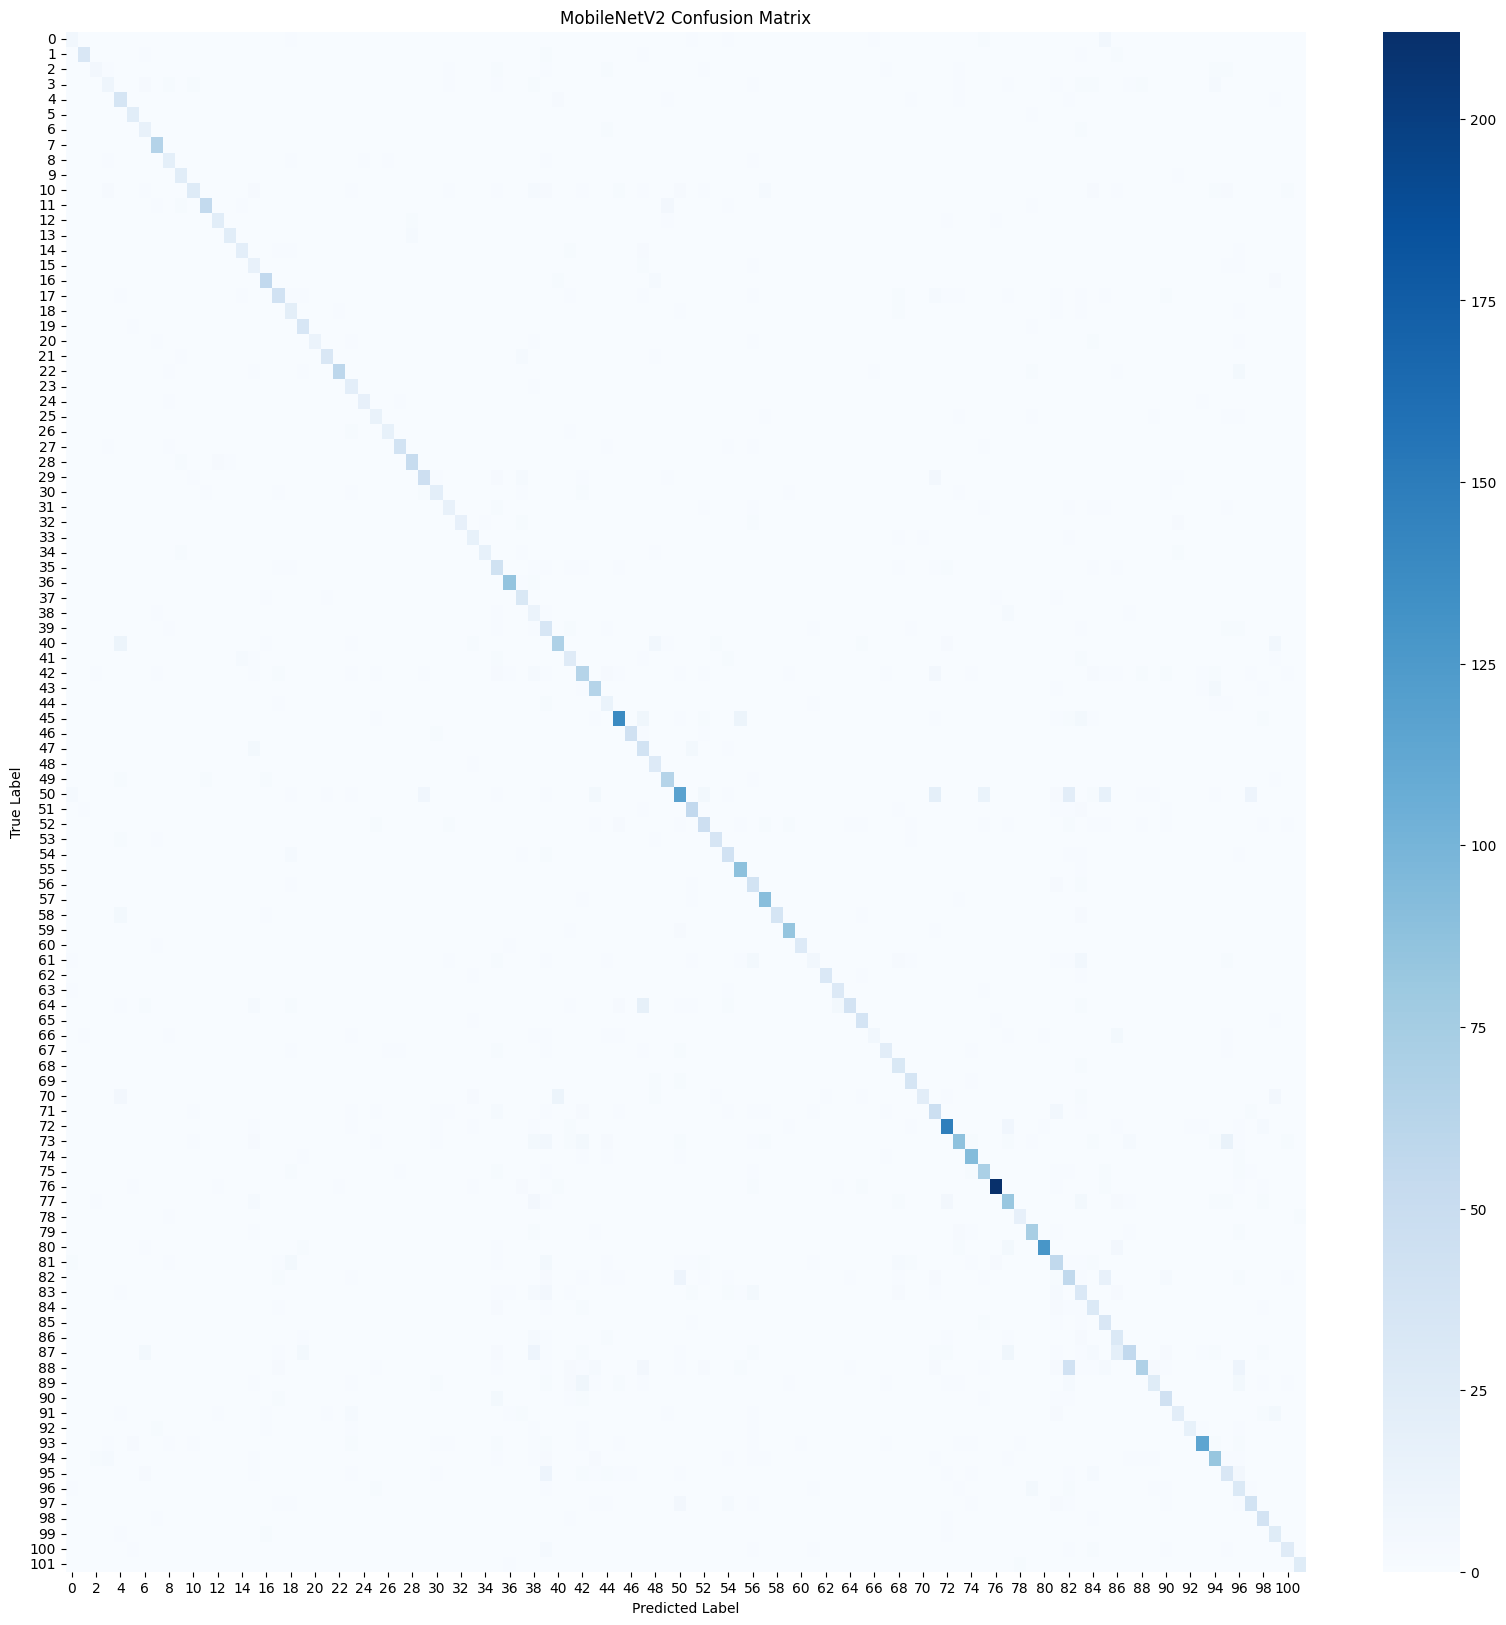

In [35]:
plt.figure(figsize=(20,20))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

###**Save MobileNetV2 Evaluation Results**

**MobileNetV2 Evaluation**

Accuracy  = 73.13%

Precision = 73.64%

Recall    = 74.22%

F1 Score  = 71.94%

#**Build ResNet50V2 Model**

Load Pretrained ResNet50V2

In [43]:
base_model_resnet = tf.keras.applications.ResNet50V2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model_resnet.trainable = False

Build ResNet50V2 Model

In [44]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model_resnet(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    ds_info.features["label"].num_classes,
    activation="softmax"
)(x)

resnet_model = tf.keras.Model(inputs, outputs)

Display ResNet50V2 Architecture

In [45]:
resnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │       208,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,773,798 (90.69 MB)

 Trainable params: 208,998 (816.40 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

###**Compile ResNet50V2**

In [46]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

###**Create New Callbacks for ResNet50V2**

In [47]:
early_stopping_resnet = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr_resnet = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

Train Frozen ResNet50V2

In [48]:
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[early_stopping_resnet, reduce_lr_resnet]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 473ms/step - accuracy: 0.0706 - loss: 4.6426 - val_accuracy: 0.3108 - val_loss: 3.1272 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.4814 - loss: 2.3098 - val_accuracy: 0.5902 - val_loss: 2.0756 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.7647 - loss: 1.3103 - val_accuracy: 0.6784 - val_loss: 1.6311 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.8627 - loss: 0.8788 - val_accuracy: 0.7098 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.9294 - loss: 0.5937 - val_accuracy: 0.7343 - val_loss: 1.2684 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.9667 - loss: 0.4249 - val_accuracy: 0.7451 - val_loss: 1.1845 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.9716 - loss: 0.3355 -

###**Evaluate ResNet50V2**

In [51]:
test_loss, test_acc = resnet_model.evaluate(test_ds)

print("ResNet50V2 Test Accuracy:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.7497 - loss: 1.1013
ResNet50V2 Test Accuracy: 0.7497153878211975


###Fine-Tune ResNet50V2

In [52]:
base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:-30]:
    layer.trainable = False
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=[early_stopping_resnet, reduce_lr_resnet]
)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 613ms/step - accuracy: 0.7373 - loss: 1.0524 - val_accuracy: 0.7775 - val_loss: 1.0294 - learning_rate: 1.0000e-05
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8407 - loss: 0.7378
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.8892 - loss: 0.6201 - val_accuracy: 0.7686 - val_loss: 1.0600 - learning_rate: 1.0000e-05
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9382 - loss: 0.4526 - val_accuracy: 0.7500 - val_loss: 1.1442 - learning_rate: 2.0000e-06
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9460 - loss: 0.4407
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.9471 - loss: 0.4328 - val_accuracy: 0.7304 - val_loss: 1.2284 - learning_rate: 2.0000e-06


In [53]:
test_loss, test_acc = resnet_model.evaluate(test_ds)

print("Fine-Tuned ResNet50V2 Accuracy:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.7538 - loss: 1.1228
Fine-Tuned ResNet50V2 Accuracy: 0.7537810802459717


###**Generate Predictions for Final ResNet50V2**

In [54]:
y_true_resnet = []
y_pred_resnet = []

for images, labels in test_ds:

    predictions = resnet_model.predict(images, verbose=0)

    predicted_labels = tf.argmax(predictions, axis=1)

    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(predicted_labels.numpy())

**Calculate Evaluation Metricsِ**

In [55]:
accuracy_resnet = accuracy_score(
    y_true_resnet,
    y_pred_resnet
)

precision_resnet = precision_score(
    y_true_resnet,
    y_pred_resnet,
    average='macro'
)

recall_resnet = recall_score(
    y_true_resnet,
    y_pred_resnet,
    average='macro'
)

f1_resnet = f1_score(
    y_true_resnet,
    y_pred_resnet,
    average='macro'
)

print("Accuracy :", accuracy_resnet)
print("Precision:", precision_resnet)
print("Recall   :", recall_resnet)
print("F1 Score :", f1_resnet)

Accuracy : 0.7537811026183119
Precision: 0.723366678026282
Recall   : 0.7659428251146471
F1 Score : 0.7319244683750057


###**Confusion Matrix for ResNet50V2**

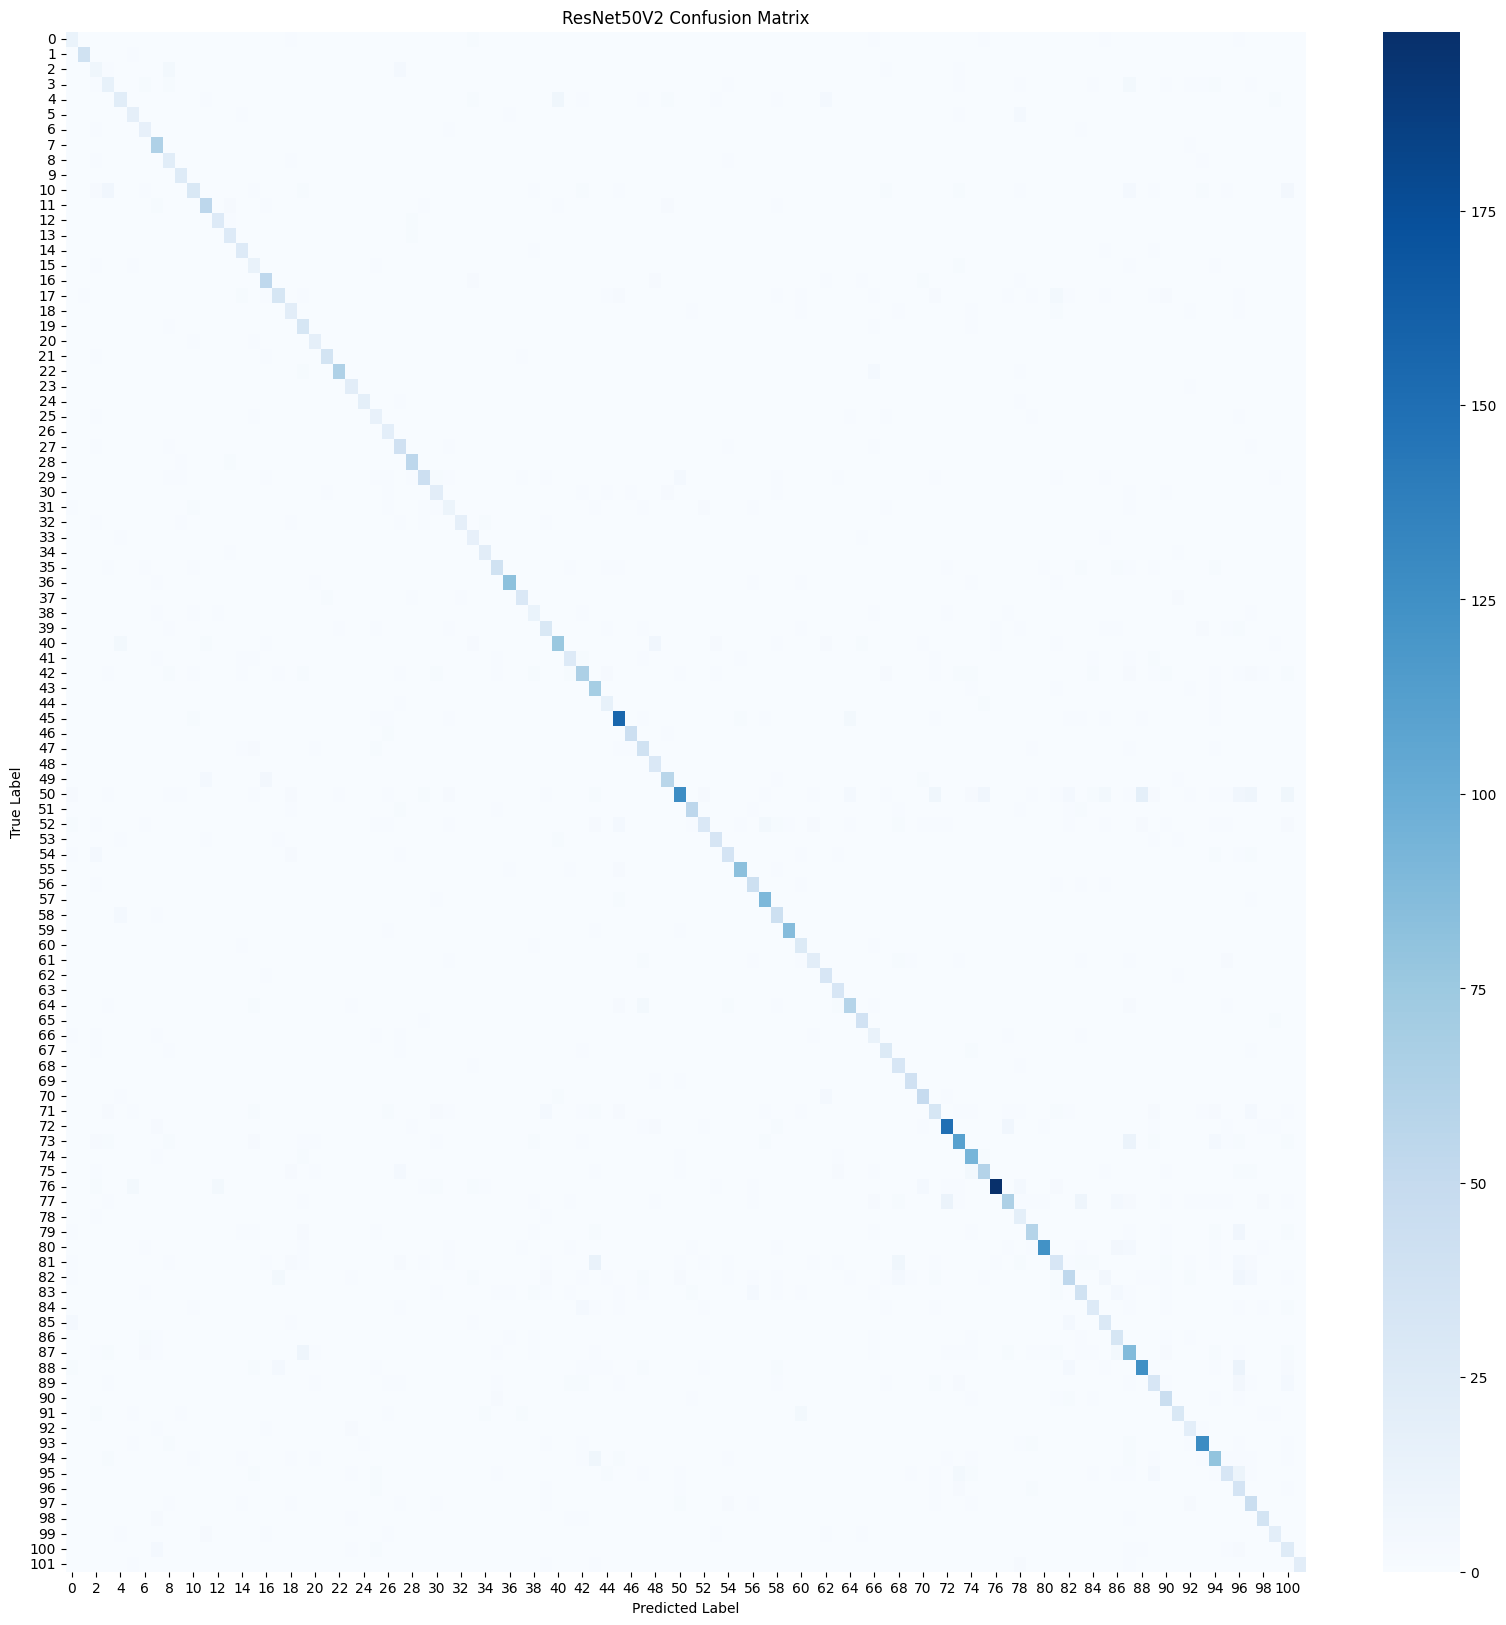

In [56]:
cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

plt.figure(figsize=(20,20))

sns.heatmap(
    cm_resnet,
    cmap="Blues"
)

plt.title("ResNet50V2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

###**Error Analysis**

In [58]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_ds:

    predictions = resnet_model.predict(images, verbose=0)

    predicted_labels = tf.argmax(predictions, axis=1)

    for i in range(len(labels)):

        if labels[i] != predicted_labels[i]:

            misclassified_images.append(images[i])
            misclassified_true.append(labels[i].numpy())
            misclassified_pred.append(predicted_labels[i].numpy())

###**Save Best Model**

In [59]:
resnet_model.save("best_flower_classifier.keras")

# **Performance Comparison of Transfer Learning Models**


| Model | Accuracy | Precision | Recall | Macro F1 |
|---------|---------|---------|---------|---------|
| MobileNetV2 | 73.13% | 73.64% | 74.22% | 71.94% |
| ResNet50V2 | 75.38% | 72.34% | 76.59% | 73.19% |

#**Visualize Misclassified Images**

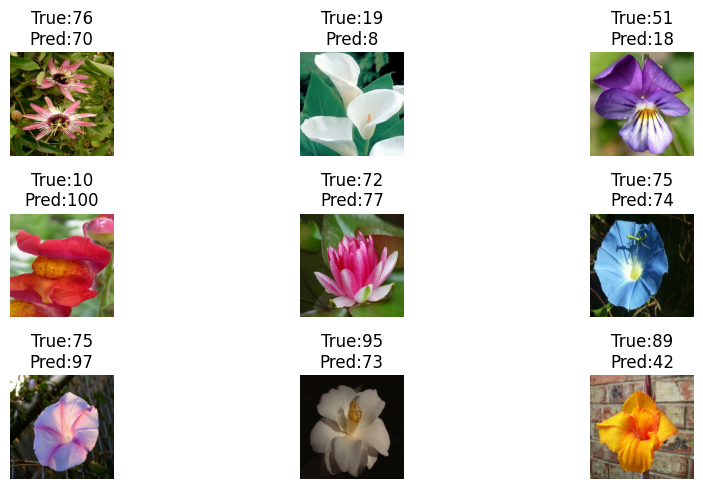

In [61]:
plt.figure(figsize=(10,5))

for i in range(min(9, len(misclassified_images))):
    plt.subplot(3,3,i+1)

    plt.imshow(misclassified_images[i])

    plt.title(
        f"True:{misclassified_true[i]}\nPred:{misclassified_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#**Conclusion**

In this project, two transfer learning models were evaluated for flower classification using the Oxford Flowers 102 dataset.

MobileNetV2 achieved a test accuracy of 73.13% and a macro F1-score of 71.94%.

Fine-Tuned ResNet50V2 achieved the best overall performance with a test accuracy of 75.38% and a macro F1-score of 73.19%.

Therefore, Fine-Tuned ResNet50V2 was selected as the final model because it provided the highest classification performance.